In [ ]:
import os
import ast
import pandas as pd
import random
import csv
from typing import Literal
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field

# Set API key manually
os.environ["ANTHROPIC_API_KEY"] = ""

MAX_SENTENCES = 5
CSV_FILE = "approved_sentences_12.csv"

In [4]:
train_set_16 = pd.read_csv('//home/s6moakba/InstructABSA/Dataset/SemEval16/Train/Restaurants_Train.csv')
train_set_16['aspectTerms'] = train_set_16['aspectTerms'].apply(ast.literal_eval)
train_set_16['aspect'] = train_set_16['aspectTerms'].apply(lambda x: [d['term'] for d in x])
train_set_16['polarity'] = train_set_16['aspectTerms'].apply(lambda x: [d['polarity'] for d in x])
training_terms = set(aspect for sublist in train_set_16['aspect'] for aspect in sublist)
training_terms.discard('noaspectterm')

In [28]:
def get_sentences():
    sampled_rows = train_set_16.sample(n=3)
    raw_text = sampled_rows['raw_text'].tolist()
    return raw_text

In [137]:
class SentenceState(BaseModel):
    sentence: str = ""  # Stores the generated sentence
    terms: str = ""  # Stores extracted aspect terms
    polarity: str = ""  # Stores polarity values
    is_ok: Literal['OK', 'NOT_OK']  
    needs_review: Literal['OK', 'NOT_OK']    # Whether the sentence requires review

In [138]:
training_polarities =  ['negative', 'positive', 'neutral','negative', 'positive', 'negative', 'positive']

In [ ]:
llm = ChatAnthropic(
    model="claude-3-5-haiku-latest",
    api_key=os.getenv("ANTHROPIC_API_KEY"),
    temperature=0.2,
    max_tokens=256
)

In [139]:
llm = ChatAnthropic(
    model="claude-3-5-sonnet-latest",
    api_key=os.getenv("ANTHROPIC_API_KEY"),
    temperature=0.2,
    max_tokens=1024
)

In [140]:
import random
def get_aspect():
        label_len = random.randint(1, 3)
        aspec_terms = random.sample(list(training_terms),label_len)
        polarities = random.sample(training_polarities,label_len)
        terms = [aspec_terms,polarities]
        return terms

In [141]:
def review_sentence_quality (text, aspect, polarity):
    sentence_length = len(text.split())

    aspect_list = ast.literal_eval(aspect)
    aspect_count = len(aspect_list)
    print('sentence length : ', sentence_length)
    print('aspect count : ', aspect_count)
    Quality_metric = "OK"
    if sentence_length < 15 and aspect_count < 2:
        Quality_metric = "NOT_OK"
        print('quality control failed')
    return Quality_metric

In [142]:
class SentenceGen(BaseModel):
    sentence: str = Field(None, description="The generated sentence.")
    Terms: list = Field(None, description="The aspect term used.")
    Polarity: list = Field(None, description="The polarity of the aspect term.")

structured_llm_gen = llm.with_structured_output(SentenceGen)

In [143]:
class SentenceEval(BaseModel):
    Eval: Literal['OK', 'NOT_OK'] = Field(None, description="Evaluation result.")

structured_llm_eval = llm.with_structured_output(SentenceEval)

In [ ]:
# text = 'Big Wong is a fantastic place with amazing food and service.'
# prompt = f"""
#     You are an expert in linguistic evaluation. Your task is to check if the given aspect terms are correct for the provided sentence.
    
#     - If ALL aspect terms appear as actual aspects in the sentence, respond **only** with: OK
#     - If any term is missing, incorrect, or not an aspect of the sentence, respond **only** with: NOT_OK

#     Do not provide explanations or any other text.

#     Input:
#     {text}
#     """
# structured_llm_eval.invoke(prompt)

SentenceEval(Eval='OK')

In [144]:
@tool
def generate_sentences() -> str:
    """Generates a sentence containing an aspect term."""
    terms = get_aspect()
    aspect_term = terms[0]
    polarity = terms[1]
    print('Selected terms:', aspect_term)
    print('Selected polarities:', polarity)
    prompt = f"""Generate a sentence using this aspect term: {', '.join(aspect_term)} with the following polarities : {', '.join(polarity)}.
    - Examples : 
    - ['food', 'portions'] ['negative', 'negative']
    - The food was lousy - too sweet or too salty and the portions tiny. 
    - Bad Example : 
    - ['soup'],['positive']
    - The udon soup was rich and flavorful (correct term was soup)
    Respond **only** with the sentence. Do not include explanations."""
    response = structured_llm_gen.invoke(prompt)
    print('Sentence generated')
    return response

@tool
def evaluate_sentence(text: str) -> str:
    """
    Evaluates if the provided aspect terms are correctly present in the sentence.
    Responds only with 'OK' or 'NOT_OK'.
    """
    print('Evaluating sentence')
    prompt = f"""
    You are an expert in linguistic evaluation. Your task is to check if the given aspect terms are correct for the provided sentence.
    
    - If ALL aspect terms appear as actual aspects in the sentence, respond **only** with: OK
    - If any term is missing, incorrect, or not an aspect of the sentence, respond **only** with: NOT_OK

    Do not provide explanations or any other text.

    Input:
    {text}
    """
    return llm.invoke(prompt)

In [145]:
generator_agent = create_react_agent(
    llm,
    tools=[generate_sentences],
    prompt="""You are a sentence generator. You can generate a new sentence.
            generate_sentences` to create a new sentence."""
)

evaluator_agent = create_react_agent(
    llm,
    tools=[evaluate_sentence],
    prompt="You are an evaluator. Your task is to determine if the given aspect terms are correct for the sentence."
    "TO evaluate, use the `evaluate_sentence` tool. Tool expects a string that includes:  1. sentence 2. aspect terms 3. polarities."
    " Respond strictly with 'OK' if all terms are correct, or 'NOT_OK' if any term is incorrect."
    " Do not provide explanations or any other text."
)

In [ ]:
import re

def generator_node(state: SentenceState):
    """Node for generating or fixing sentences."""
    print('in generator node')

    result = generator_agent.invoke({"messages": [HumanMessage(content="Generate a new sentence.")]})
    message_content = result["messages"][-2].content
    
    
    print('generator node result:', result["messages"][-2].content.strip())

    if " Terms=" in message_content:
        sentence_part, remaining_part = message_content.split(" Terms=", 1)
        terms_part, polarity_part = remaining_part.split(" Polarity=", 1)
        
        # Remove sentence='...' structure
        final_sentence = sentence_part.replace("sentence=", "").strip().strip("'\"")
        aspect_term = terms_part.strip().strip("'\"")
        polarity = polarity_part.strip().strip("'\"")
    else:
        # Fallback if splitting fails 
        final_sentence = message_content.strip().strip("'\"")
        aspect_term = "Unknown Terms"
        polarity = "Unknown Polarity"

    print('final sentence:', final_sentence)
    print('aspect term:', aspect_term)
    print('polarity:', polarity)

    state.sentence = final_sentence
    state.terms = aspect_term
    state.polarity = polarity

    return state

def evaluator_node(state: SentenceState):
    """Node that evaluates the generated sentence."""
    print('in evaluator node')

    generate_sentence = state.sentence
    gen_terms = state.terms
    gen_polarity = state.polarity
    eval_input_format = f"{generate_sentence} Terms={gen_terms} Polarity={gen_polarity}"
    eval_input = {"messages": [HumanMessage(content=eval_input_format)]}

    result = evaluator_agent.invoke(eval_input)

    eval_response = result["messages"][-1].content
    print('evaluation response: ',eval_response)

    if eval_response not in ["OK", "NOT_OK"]:
        print("[Evaluator Node] Invalid response from LLM. Defaulting to NOT_OK.")
        eval_response = "NOT_OK"

    state.is_ok = eval_response    

    return state

def review_node(state: SentenceState):
    """Node to review the generated sentence."""
    print('in review node')

    final_sentence = state.sentence
    aspect_term = state.terms
    polarity = state.polarity

    review_result = review_sentence_quality(final_sentence, aspect_term, polarity)
    state.needs_review = review_result

    return state

def saver_node(state: SentenceState):
    """Node that saves the final approved sentence and its aspect term to a CSV file."""
    print('in saver node')
    
    final_sentence = state.sentence
    aspect_term = state.terms
    polarity = state.polarity

    csv_file = "approved_sentences.csv"

    # Ensure the file has headers if it does not exist
    file_exists = os.path.isfile(csv_file)

    with open(csv_file, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(["sentence", "Terms", "Polarity"])  # Write headers if new file
        writer.writerow([final_sentence, aspect_term, polarity])

    print(f"[Saver Node] Sentence saved: {final_sentence} | Aspect Term: {aspect_term}")

    state.sentence = ''
    state.terms = ''
    state.polarity = ''

    return state

def evaluation_decision(state: SentenceState):
    """Decides whether to loop back to generator or proceed to saver node."""
    print('in sentence evaluation decision')
    
    evaluation_result = state.is_ok

    if evaluation_result == "OK":
        return "reviewer" 

    return "generator"


In [147]:
def save_decision(state: SentenceState):
    """Decides whether to continue generating sentences or stop based on saved sentence count."""
    if os.path.isfile(CSV_FILE):
        df = pd.read_csv(CSV_FILE)
        sentence_count = len(df)
        if sentence_count < MAX_SENTENCES:
            return "generator"  # Keep generating sentences
    else:
        return "generator"  # If no file exists, continue generating

    return END

In [148]:
def review_decision(state: SentenceState):
    """Decides whether to review the generated sentence or proceed to evaluation."""
    print('in review decision')
    review_decision = state.needs_review

    if review_decision == "OK":
        return "saver"

    return "generator"

In [149]:
# Build the graph
graph = StateGraph(SentenceState)

graph.add_node("generator", generator_node)
graph.add_node("evaluator", evaluator_node)
graph.add_node("saver", saver_node)  
graph.add_node("reviewer", review_node)

graph.set_entry_point("generator")  # Entry point

graph.add_edge("generator", "evaluator")
graph.add_conditional_edges("evaluator", evaluation_decision, {"generator": "generator", "reviewer": "reviewer"})

graph.add_conditional_edges("reviewer", review_decision, {"generator": "generator", "saver": "saver"})
# graph.add_edge("saver", END)  # Saver node leads to END
graph.add_conditional_edges("saver", save_decision, {"generator": "generator", END: END})

graph = graph.compile()

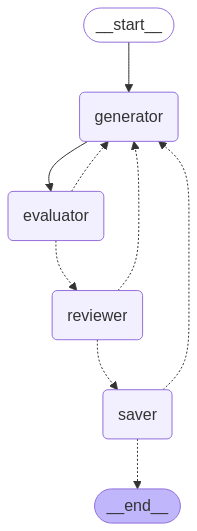

In [150]:
from IPython.display import clear_output
from IPython.display import Image
clear_output(wait=True)  # Clear previous outputs
display(Image(graph.get_graph().draw_mermaid_png()))

In [151]:
initial_state = SentenceState(
    sentence="", 
    terms="", 
    polarity="", 
    is_ok="NOT_OK", 
    needs_review="NOT_OK"
)

# Run the graph with the initial state
final_state = graph.invoke(initial_state, {"recursion_limit": 150})
# for m in messages["messages"]:
#     m.pretty_print()

in generator node
Selected terms: ['Ow Ley Soh']
Selected polarities: ['positive']
Sentence generated
generator node result: sentence='Ow Ley Soh is a talented chef who creates amazing dishes.' Terms=['Ow Ley Soh'] Polarity=['positive']
final sentence: Ow Ley Soh is a talented chef who creates amazing dishes.
aspect term: ['Ow Ley Soh']
polarity: ['positive']
in evaluator node
Evaluating sentence
evaluation response:  OK
in sentence evaluation decision
in review node
sentence length :  11
aspect count :  1
quality control failed
in review decision
in generator node
Selected terms: ['Indian Chinese', 'back room']
Selected polarities: ['negative', 'positive']
Sentence generated
generator node result: sentence='While the Indian Chinese food was disappointing and bland, the back room offered a cozy and intimate dining space.' Terms=['Indian Chinese', 'back room'] Polarity=['negative', 'positive']
final sentence: While the Indian Chinese food was disappointing and bland, the back room offer

KeyboardInterrupt: 